In [1]:
import os
import pypsa
import pycountry
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from pathlib import Path

from unit_helpers import (
    tj_to_twh,
    bcm_to_twh,
)

from data_preparing import (
    plot_total_gas_supply,
    add_shared_row_title,
    basic_axis_formatting,
    plot_stacked_bars,
    get_model_pipeline_imports,
    plot_pipeline_imports,
    plot_eu_gas_stock,
    plot_residential_commercial_demand,
    plot_industry_demand,
    industry_demands,
    rescom_demands,
    plot_country_consumption,
    plot_electricity_mix,
)

/home/lukas/micromamba/envs/pypsa-eur/lib/python3.12/site-packages/google/cloud/storage/__init__.py:35: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution


In [2]:
path = Path.cwd().parent / 'resources'
regions = gpd.read_file(path / 'regions_onshore_base_s_50.geojson')
path = Path.cwd().parent / 'results' / 'networks'
n = pypsa.Network(path / 'base_s_50_24H_24H-T-H-B-I-A-dist1_2025.nc')

/home/lukas/micromamba/envs/pypsa-eur/lib/python3.12/site-packages/pyogrio/__init__.py:7: DeprecationWarning: The 'shapely.geos' module is deprecated, and will be removed in a future version. All attributes of 'shapely.geos' are available directly from the top-level 'shapely' namespace (since shapely 2.0.0).
  import shapely.geos  # noqa: F401
INFO:pypsa.io:Imported network base_s_50_24H_24H-T-H-B-I-A-dist1_2025.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


In [3]:
from gas_validation_data import (
    df_2024_residential,
    df_2024_industrial,
    df_2024_production,
    df_pipeline_imports,
    df_total_supply,
    df_storage_2024,
    df_2024_power,
)

df_2024_residential = bcm_to_twh(df_2024_residential)
df_2024_industrial = bcm_to_twh(df_2024_industrial)
df_2024_production = bcm_to_twh(df_2024_production)
df_pipeline_imports = bcm_to_twh(df_pipeline_imports)
df_total_supply = bcm_to_twh(df_total_supply)
df_storage_2024 = bcm_to_twh(df_storage_2024)
df_2024_power = bcm_to_twh(df_2024_power)

ccon = pd.read_csv(
    'nrg_cb_gas$defaultview_linear_2_0.csv'
)
ccon = (
    ccon.loc[ccon['TIME_PERIOD'] == 2024]
    .set_index('Geopolitical entity (reporting)')
    ['OBS_VALUE']
    .rename('gas_demand')
    .apply(tj_to_twh)
)

def country_name_to_iso2(name):
    name = name.strip()
    try:
        return pycountry.countries.lookup(name).alpha_2
    except LookupError:
        return None

ccon = ccon.copy()
ccon.index = ccon.index.map(country_name_to_iso2)
ccon = ccon[~ccon.index.isnull()]
ccon = ccon.sort_values(ascending=False)

In [4]:
gens = n.generators.index[n.generators.carrier == 'gas']

In [5]:
def plot_power_demand(ax_left, ax_right, n, right_data, fig, i):

    add_shared_row_title(fig, ax_left, ax_right, "EU-27 + UK Power Sector Gas Demand", i)

    powergas = n.links.index[n.links.carrier.isin(['OCGT', 'CCGT'])]
    gas_consumption = n.links_t.p0[powergas].sum(axis=1).mul(n.snapshot_weightings['generators']).mul(1e-6)
    gas_consumption = gas_consumption.groupby(gas_consumption.index.month).sum()

    model_data = gas_consumption.copy()
    model_data.index = right_data.index

    ylim_lower = min(0, right_data.min(), model_data.min())
    ylim_upper = max(right_data.max(), model_data.max())

    pad = 1.1

    ax_left.plot(model_data.index, model_data.values, marker='o', color='royalblue')
    ax_right.plot(right_data.index, right_data.values, marker='o', color='royalblue')

    ax_left.set_ylim(ylim_lower, ylim_upper * pad)
    ax_right.set_ylim(ylim_lower, ylim_upper * pad)

    for ax in [ax_left, ax_right]:
        basic_axis_formatting(ax)

yet to implement other pipeline representation in model!


INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should

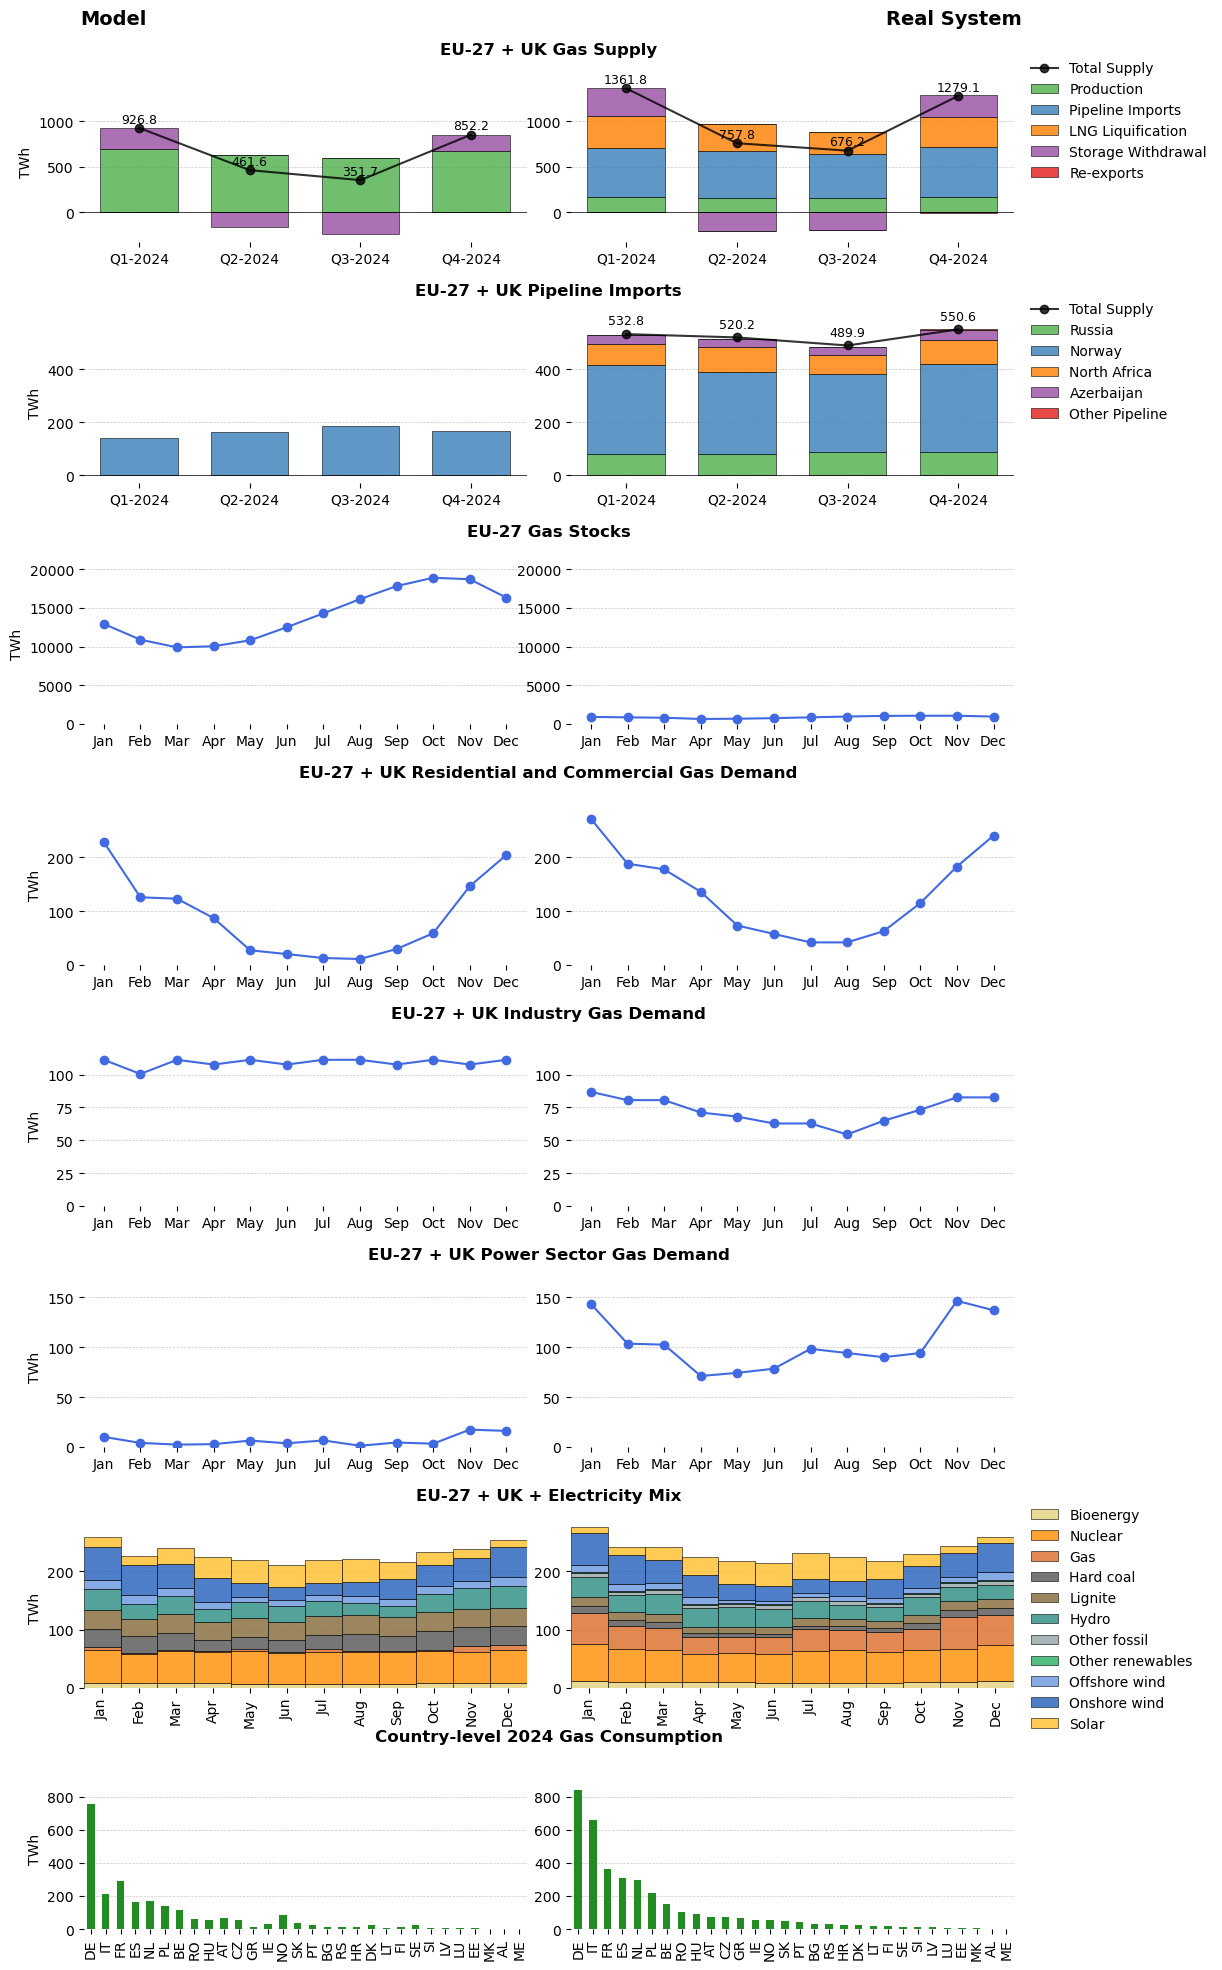

In [6]:
nrows = 8

fig_height = 3 * nrows  # 3 inches per row
fig_width = 12      # 2*2*3 = 12 inches for 2:1 aspect per ax, 2 axes per row
fig, axes = plt.subplots(
    nrows=nrows,
    ncols=2,
    figsize=(fig_width, fig_height),
    gridspec_kw={'wspace':0.1, 'hspace':0.5}
    )

row_fns = [
    plot_total_gas_supply,
    plot_pipeline_imports,
    plot_eu_gas_stock,
    plot_residential_commercial_demand,
    plot_industry_demand,
    plot_power_demand,
    plot_electricity_mix,
    plot_country_consumption,
]

right_data_list = [
    df_total_supply,
    df_pipeline_imports,
    df_storage_2024,
    df_2024_residential,
    df_2024_industrial,
    df_2024_power,
    None,
    ccon,
]

for i in range(nrows):
    model_ax = axes[i, 0]
    true_ax = axes[i, 1]
    row_fns[i](model_ax, true_ax, n, right_data_list[i], fig, i)

    model_ax.set_xlabel("")
    model_ax.set_ylabel("")
    true_ax.set_xlabel("")
    true_ax.set_ylabel("")

    fig.canvas.draw()  # Needed to ensure positions are up to date
    bbox1 = model_ax.get_position()
    bbox2 = true_ax.get_position()

    x0 = bbox1.x1 - 0.02 * (bbox2.x0 - bbox1.x1)  # slight overlap
    width = bbox2.x0 - bbox1.x1 + 0.04 * (bbox2.x0 - bbox1.x1)
    y0 = bbox1.y0
    height = bbox1.height

    bbox_top = model_ax.get_position()
    bbox_bottom = model_ax.get_position()
    y0 = bbox_bottom.y0
    height = (bbox_top.y1 - bbox_bottom.y0) / 5

    '''
    rect = patches.FancyBboxPatch(
        (x0, y0), width, height,
        boxstyle="round,pad=0.02",
        linewidth=1, edgecolor='gray', facecolor='white', alpha=0.95,
        transform=fig.transFigure, zorder=10
    )

    fig.patches.append(rect)

    fig.text(
        x0 + width/2, y0 + height/2,
        f"Legend/Explanation\nPlaceholder\n(Row {i+1})",
        ha='center', va='center', fontsize=10, color='black', zorder=11
    )
    '''

fig.text(0.15, 0.91, 'Model', ha='center', va='top', fontsize=14, fontweight='bold')
fig.text(0.85, 0.91, 'Real System', ha='center', va='top', fontsize=14, fontweight='bold')

for ax in axes[:,0]:
    ax.set_ylabel('TWh')

# plt.savefig('validation_starting_point.pdf', bbox_inches='tight')
plt.show()

In [164]:
ss = n.statistics.energy_balance(groupby=['carrier', 'bus'])

ss.loc[
    (ss.index.get_level_values(2).str.contains('gas')) &
    (ss.index.get_level_values(2).str.contains('NO')) &
    (ss.index.get_level_values(1) == 'gas pipeline')
]

component  carrier       bus      
Link       gas pipeline  NO1 0 gas   -662.71861
dtype: float64

In [100]:
pipes = n.links.index[n.links.carrier == 'gas pipeline']

In [27]:
def get_link_data(c):
    l = n.links.index[n.links.carrier == c]

    cols = ['marginal_cost', 'efficiency', 'capital_cost', 'p_nom', 'p_nom_opt']
    print(n.links.loc[[l[0]], cols])

In [28]:
get_link_data('OCGT')

                 marginal_cost  efficiency  capital_cost  p_nom  p_nom_opt
Link                                                                      
AL0 0 OCGT-2025       1.937854       0.405  19739.577493    0.0   0.024545


In [29]:
get_link_data('CCGT')

                 marginal_cost  efficiency  capital_cost  p_nom  p_nom_opt
Link                                                                      
AL0 0 CCGT-2025       2.603971        0.57   61475.63654    0.0   0.009458


In [30]:
get_link_data('coal')

                 marginal_cost  efficiency   capital_cost        p_nom  \
Link                                                                     
DE0 2 coal-1950       1.170296       0.356  120046.057771  2134.831461   

                   p_nom_opt  
Link                          
DE0 2 coal-1950  2134.831461  


In [37]:
ss = n.links.loc[n.links.carrier.isin(['OCGT', 'CCGT', 'coal', 'lignite'])]
ss.groupby('carrier')[['p_nom', 'p_nom_opt']].sum() / 1e3

,p_nom,p_nom_opt
carrier,,
CCGT,320.815959,332.948561
OCGT,0.057556,0.058830
coal,137.859267,137.859267
lignite,157.953647,157.953647


In [36]:
n.generators.loc[n.generators.carrier.isin(['gas', 'coal', 'lignite']), ['marginal_cost', 'capital_cost', 'carrier']].groupby('carrier').mean()

,marginal_cost,capital_cost
carrier,,
coal,9.564171,0.0
gas,24.578086,0.0
lignite,3.308927,0.0


In [40]:
prices = pd.read_csv(
    Path.cwd().parent / 'data' / 'TERMINAL - PA historical - 2025-10-21.csv', index_col=0, parse_dates=True
)

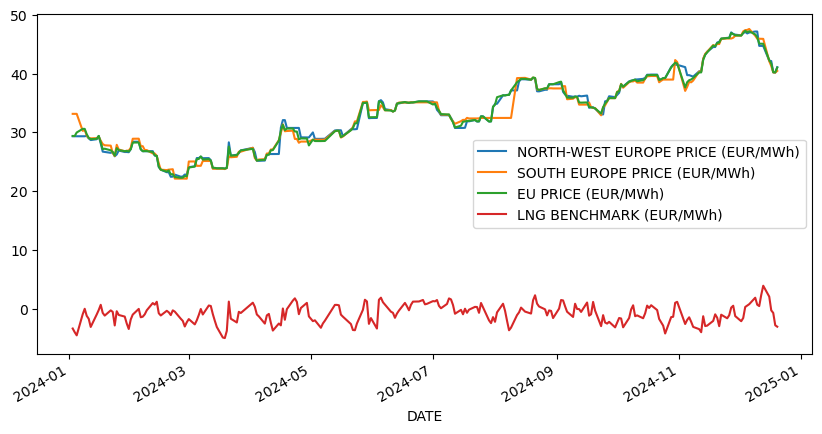

In [86]:
fig, ax = plt.subplots(figsize=(10, 5))
prices.index = pd.to_datetime(prices.index)
prices.loc['2024'].plot(ax=ax)
plt.show()

In [87]:
wbprices = pd.read_excel(
    Path.cwd().parent / 'data' / 'CMO-Historical-Data-Monthly.xlsx', sheet_name='Monthly Prices', header=[4,5,6], index_col=0, parse_dates=True,
)
wbprices = wbprices.loc[wbprices.index.str.contains('2024')]

gas_keepers = ['Natural gas, Europe', 'Liquefied natural gas, Japan']
coal_keepers = ['Coal, Australian', 'Coal, South African **']

wbprices = wbprices.loc[:, gas_keepers + coal_keepers]
wbprices.index = list(map(lambda x: f'{x[:4]}-{x[-2:]}', wbprices.index))

wbprices.columns = wbprices.columns.get_level_values(0)

wbprices.loc[:, gas_keepers] *= 3.152 # conversion from $/MMBtu to EUR/MWh

wbprices.loc[:, 'Lignite'] = 0.1325 * 6000 / 2800 * wbprices.loc[:, 'Coal, Australian']
 # conversion from $/tonne to EUR/MWh (given caloric value read from Description sheet, 6000kcal/kg)
wbprices.loc[:, 'Coal, Australian'] *= 0.1325 # conversion from $/tonne to EUR/MWh (given caloric value read from Description sheet, 6000kcal/kg)
wbprices.loc[:, 'Coal, South African **'] *= 0.1325 # conversion from $/tonne to EUR/MWh (given caloric value read from Description sheet, 6000kcal/kg)

wbprices.rename(
    columns={
        'Natural gas, Europe': 'Europe gas',
        'Liquefied natural gas, Japan': 'Japan LNG',
        'Coal, Australian': 'Australia coal',
        'Coal, South African **': 'South Africa coal',
    },
    inplace=True,
)
wbprices.index = pd.to_datetime(wbprices.index)

/tmp/ipykernel_1444421/3515084156.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  wbprices = pd.read_excel(


In [70]:
em = pd.read_csv(
    Path.cwd().parent / 'data' / 'europe_monthly_full_release_long_format.csv', index_col=[1,2]
)

em = em.loc[
    (em['Unit'] == 'TWh') &
    (em['Subcategory'] == 'Fuel')
    ]

In [72]:
em = em.set_index('Variable', append=True)
em = em.loc[em.Area.isin(['EU', 'United Kingdom'])]

em = em.groupby([em.index.get_level_values(2), em.index.get_level_values(1).str[:7]])['Value'].sum().unstack()
em = em.loc[:, em.columns.str.contains('2024')]

In [73]:
em.sum().sum()

2825.89

In [8]:
n.loads.carrier.unique()

array(['electricity', 'land transport EV', 'land transport oil',
       'urban central heat', 'solid biomass for industry',
       'gas for industry', 'H2 for industry', 'industry methanol',
       'naphtha for industry', 'low-temperature heat for industry',
       'industry electricity', 'process emissions', 'NH3',
       'coal for industry', 'shipping oil', 'kerosene for aviation',
       'agriculture electricity', 'agriculture heat',
       'agriculture machinery electric', 'agriculture machinery oil',
       'rural heat', 'urban decentral heat'], dtype=object)

In [ ]:
w = n.snapshot_weightings.generators.iloc[0]

In [63]:
el = n.loads.index[(n.loads.carrier == 'electricity') & (~n.loads.index.str.contains(' NO'))]
total_elec_load = (
    n.loads.loc[
        n.loads.carrier.isin(['agriculture electricity', 'industry electricity']) &
        (~n.loads.index.str.contains(' NO')),
        'p_set'].sum() * len(n.snapshots) +
    n.loads_t.p_set.loc[:, el].sum().sum()
) * w * 1e-6
withdrawers = n.links.loc[list(map(lambda x: 'low voltage' in x, n.links.bus0))].index
withdrawers = withdrawers[~withdrawers.str.contains('NO ')]
heating_transport_demand = n.links_t.p0.loc[:, withdrawers].sum().sum() * w * 1e-6

total_elec_load += heating_transport_demand
total_elec_load

3108.7883803355016

In [53]:
n.links.carrier.unique()

array(['DC', 'oil refining', 'co2 sequestered', 'OCGT', 'CCGT',
       'H2 Electrolysis', 'gas pipeline', 'gas pipeline new',
       'battery charger', 'battery discharger', 'Sabatier', 'SMR CC',
       'SMR', 'BEV charger', 'V2G', 'land transport oil',
       'urban central air heat pump', 'urban central gas boiler',
       'urban central gas CHP', 'urban central gas CHP CC',
       'unsustainable bioliquids', 'biogas to gas',
       'urban central solid biomass CHP',
       'urban central solid biomass CHP CC', 'biomass to liquid',
       'electrobiofuels', 'Haber-Bosch', 'ammonia cracker',
       'biomass-to-methanol', 'OCGT methanol',
       'solid biomass for industry', 'solid biomass for industry CC',
       'gas for industry', 'gas for industry CC', 'industry methanol',
       'methanolisation', 'Fischer-Tropsch', 'naphtha for industry',
       'HVC to air', 'process emissions', 'process emissions CC',
       'coal for industry', 'shipping oil', 'kerosene for aviation',
       '

In [ ]:
total_elec_load

In [ ]:
rl = pd.read_csv(
    Path.cwd().parent / 'data' / 'europe_monthly_full_release_long_format.csv', index_col=[1,2]
)
rl = rl.loc[(rl.Subcategory == 'Demand') & (rl.Area != 'EU')].groupby(level=1)['Value'].sum()
rl.loc[rl.index.str.contains('2024')].sum()

3457.31

In [47]:
import xarray as xr
# rawdemand = xr.open_dataset(
rawdemand = pd.read_csv(
    Path.cwd().parent / 'resources' / 'electricity_demand.csv', index_col=0, parse_dates=True
)


In [ ]:
rawdemand.drop(columns=['NO']).sum().sum()

3075962645.706654

In [32]:
ns = n.statistics.energy_balance(aggregate_time=False)# .loc[idx[:,:,'AC']]
ns

snapshot                                                             2024-01-01  \
component carrier                        bus_carrier                              
Load      H2 for industry                Hydrogen Storage            1003.42466   
          NH3                            NH3                        -9965.75342   
          agriculture electricity        low voltage                -4283.77669   
          agriculture heat               residential rural heat    -24521.88843   
          agriculture machinery electric low voltage                -2515.84243   
...                                                                         ...   
Generator unsustainable biogas           biogas                     22584.08407   
          unsustainable bioliquids       unsustainable bioliquids   22142.16236   
          unsustainable solid biomass    solid biomass             155060.73857   
          urban central heat vent        urban central heat          -338.60812   
          urban central solar thermal    urban central heat                 NaN   

snapshot                                                             2024-01-02  \
component carrier                        bus_carrier                              
Load      H2 for industry                Hydrogen Storage            1003.42466   
          NH3                            NH3                        -9965.75342   
          agriculture electricity        low voltage                -4283.77669   
          agriculture heat               residential rural heat    -24521.88843   
          agriculture machinery electric low voltage                -2515.84243   
...                                                                         ...   
Generator unsustainable biogas           biogas                     22584.08432   
          unsustainable bioliquids       unsustainable bioliquids   22108.71378   
          unsustainable solid biomass    solid biomass             155727.44407   
          urban central heat vent        urban central heat          -478.13154   
          urban central solar thermal    urban central heat                 NaN   

snapshot                                                             2024-01-03  \
component carrier                        bus_carrier                              
Load      H2 for industry                Hydrogen Storage            1003.42466   
          NH3                            NH3                        -9965.75342   
          agriculture electricity        low voltage                -4283.77669   
          agriculture heat               residential rural heat    -24521.88843   
          agriculture machinery electric low voltage                -2515.84243   
...                                                                         ...   
Generator unsustainable biogas           biogas                     22584.08433   
          unsustainable bioliquids       unsustainable bioliquids   22110.52801   
          unsustainable solid biomass    solid biomass             154468.07767   
          urban central heat vent        urban central heat          -684.31573   
          urban central solar thermal    urban central heat                 NaN   

snapshot                                                             2024-01-04  \
component carrier                        bus_carrier                              
Load      H2 for industry                Hydrogen Storage            1003.42466   
          NH3                            NH3                        -9965.75342   
          agriculture electricity        low voltage                -4283.77669   
          agriculture heat               residential rural heat    -24521.88843   
          agriculture machinery electric low voltage                -2515.84243   
...                                                                         ...   
Generator unsustainable biogas           biogas                     22584.08436   
          uns

In [38]:
keepers = [
    'Pumped Hydro Storage',
    'Reservoir & Dam',
    'Offshore Wind (AC)',
    'Offshore Wind (DC)',
    'Offshore Wind (Floating)',
    'Onshore Wind',
    'Run of River',
    'Solar',
    'nuclear',
    'lignite',
    'solar-hsat',
    'Combined-Cycle Gas',
    'Open-Cycle Gas',
    'coal',
    'urban central gas CHP CC',
    'urban central solid biomass CHP',
    'urban central solid biomass CHP CC',
]
grouper = {
    "Offshore Wind (AC)": "Offshore wind",
    "Offshore Wind (DC)": "Offshore wind",
    "Offshore Wind (Floating)": "Offshore wind",
    "Onshore Wind": "Onshore wind",
    "Run of River": "Hydro",
    "Pumped Hydro Storage": "Hydro",
    "Reservoir & Dam": "Hydro",
    "urban central gas CHP CC": "Gas",
    "urban central solid biomass CHP CC": "Bioenergy",
    "urban central solid biomass CHP": "Bioenergy",
    "Open-Cycle Gas": "Gas",
    "Combined-Cycle Gas": "Gas",
    "coal": "Hard coal",
    "lignite": "Lignite",
    "nuclear": "Nuclear",
    "solar": "Solar",
    "solar-hsat": "Solar",
}
grouper = {
    origin: grouper.get(origin, origin) for origin in keepers
}


In [41]:
idx = pd.IndexSlice

remove_countries = ['NO', 'AL', 'BA', 'ME', 'MK', 'NO', 'RS', 'XK']

ns = n.statistics.energy_balance(groupby=['bus', 'carrier'], aggregate_time=False)
ns = ns.loc[~ns.index.get_level_values(1).str.startswith(tuple(remove_countries))]
ns = ns.loc[ns.index.get_level_values(1) != '']

ns = ns.loc[list(map(lambda x: n.buses.loc[x, 'carrier'] == 'AC', ns.index.get_level_values(1)))]
ns = ns.groupby(level=2).sum()
# 
# ns.index = ns.index.get_level_values(1)

ns = ns.groupby(grouper).sum().T
ns

carrier,Bioenergy,Gas,Hard coal,Hydro,Lignite,Nuclear,Offshore wind,Onshore wind,Solar
snapshot,,,,,,,,,
2024-01-01,12819.87080,4627.84030,37898.69618,39111.35098,43339.57897,74890.85773,23817.57652,86657.15118,17828.29280
2024-01-02,12999.46662,4194.47731,40760.73605,39786.41819,43339.57931,74747.25219,24607.57871,109007.73835,9120.31297
2024-01-03,12701.60848,2715.23157,29670.66221,37520.85130,43339.57262,74668.37188,23861.00092,124831.69966,13709.07322
2024-01-04,13515.26546,6992.17646,48837.05760,56928.59461,43339.59032,74827.62268,16741.03522,78563.99983,15551.88234
2024-01-05,13508.38538,11952.71486,48837.55953,61512.23008,43339.59906,74798.59848,20525.45287,59322.57601,14041.43142
...,...,...,...,...,...,...,...,...,...
2024-12-27,12088.46389,41371.62003,47386.43098,79476.09863,43339.61448,74862.42196,3062.42242,19328.13143,22719.22246
2024-12-28,12228.08795,26376.15863,47386.59912,71347.27640,43339.61374,74878.62730,8060.88238,16656.91455,23587.03514
2024-12-29,11731.08460,8215.18000,47258.01168,53323.07335,43339.60128,74874.99547,20512.67783,51165.67241,21204.85406


In [27]:
ns.loc[idx[:,'',:]]

snapshot                                    2024-01-01  2024-01-02  \
component carrier                                                    
Link      BEV charger                              NaN         NaN   
          CO2 pipeline                             NaN         NaN   
          Combined-Cycle Gas                       NaN         NaN   
          DC                                       NaN         NaN   
          Fischer-Tropsch                          NaN         NaN   
...                                                ...         ...   
          urban central gas CHP                    NaN         NaN   
          urban central gas boiler                 NaN         NaN   
          urban central solid biomass CHP          NaN         NaN   
          urban decentral oil boiler               NaN         NaN   
          urban decentral resistive heater         NaN         NaN   

snapshot                                    2024-01-03  2024-01-04  \
component carrier                                                    
Link      BEV charger                              NaN         NaN   
          CO2 pipeline                             NaN         NaN   
          Combined-Cycle Gas                       NaN         NaN   
          DC                                       NaN         NaN   
          Fischer-Tropsch                          NaN         NaN   
...                                                ...         ...   
          urban central gas CHP                    NaN         NaN   
          urban central gas boiler                 NaN         NaN   
          urban central solid biomass CHP          NaN         NaN   
          urban decentral oil boiler               NaN         NaN   
          urban decentral resistive heater         NaN         NaN   

snapshot                                    2024-01-05  2024-01-06  \
component carrier                                                    
Link      BEV charger                              NaN         NaN   
          CO2 pipeline                             NaN         NaN   
          Combined-Cycle Gas                       NaN         NaN   
          DC                                       NaN         NaN   
          Fischer-Tropsch                          NaN         NaN   
...                                                ...         ...   
          urban central gas CHP                    NaN         NaN   
          urban central gas boiler                 NaN         NaN   
          urban central solid biomass CHP          NaN         NaN   
          urban decentral oil boiler               NaN         NaN   
          urban decentral resistive heater         NaN         NaN   

snapshot                                    2024-01-07  2024-01-08  \
component carrier                                                    
Link      BEV charger                              NaN         NaN   
          CO2 pipeline                             NaN         NaN   
          Combined-Cycle Gas                       NaN         NaN   
          DC                                       NaN         NaN   
          Fischer-Tropsch                          NaN         NaN   
...                                                ...         ...   
          urban central gas CHP                    NaN         NaN   
          urban central gas boiler                 NaN         NaN   
          urban central solid biomass CHP          NaN         NaN   
          urban decentral oil boiler               NaN         NaN   
          urban decentral resistive heater         NaN         NaN   

snapshot                                    2024-01-09  2024-01-10  ...  \
component carrier                                                   ...   
Link      BEV charger                              NaN         NaN  ...   
          CO2 pipeline                             NaN         NaN  ...   
          Combined-Cycle Gas                       NaN  

In [8]:
ns

snapshot,2024-01-01,2024-01-02,2024-01-03,2024-01-04,2024-01-05,2024-01-06,2024-01-07,2024-01-08,2024-01-09,2024-01-10,...,2024-12-22,2024-12-23,2024-12-24,2024-12-25,2024-12-26,2024-12-27,2024-12-28,2024-12-29,2024-12-30,2024-12-31
carrier,,,,,,,,,,,,,,,,,,,,,
Combined-Cycle Gas,4627.74576,4194.38403,2715.13726,6992.07236,11952.60228,13196.24851,13816.52730,8153.62886,7589.33495,13038.08903,...,2173.10999,729.54152,10185.64386,11493.38252,28036.08603,41371.49638,26376.03714,8215.07122,5639.73046,5459.90110
DC,-602.44169,-601.22363,-610.67116,-796.40914,-784.79537,-793.63863,-813.48457,-839.98089,-667.16743,-603.60369,...,-451.96682,-774.93098,-681.29303,-646.12419,-555.96964,-509.61819,-563.90369,-682.77620,-709.32803,-552.04169
H2 Electrolysis,-0.09274,-0.09330,-0.09701,-0.08980,-0.08349,-0.08154,-0.08848,-0.08660,-0.09043,-0.08381,...,-0.09733,-0.09103,-0.08068,-0.08476,-0.07997,-0.07670,-0.07737,-0.08526,-0.09128,-0.09189
Haber-Bosch,-2464.54413,-2464.54388,-2464.54475,-2464.54316,-2464.54260,-2464.54129,-2464.54283,-2464.54330,-2464.54641,-2464.54418,...,-2464.54494,-2464.54400,-2464.54278,-2464.54290,-2464.54214,-2464.54176,-2464.54200,-2464.54328,-2464.54422,-2464.54436
OCGT methanol,0.01928,0.01923,0.01908,0.01960,0.02030,0.02052,0.01993,0.01987,0.01994,0.02030,...,0.01901,0.01964,0.02085,0.02051,0.02065,0.02115,0.02089,0.02023,0.01970,0.01939
Open-Cycle Gas,0.07057,0.06986,0.06962,0.07728,0.08204,0.08313,0.07755,0.07856,0.07838,0.08546,...,0.06688,0.07258,0.08690,0.08372,0.08813,0.09087,0.08950,0.08058,0.07342,0.07123
battery charger,-0.99330,-0.99623,-1.00805,-0.97653,-0.95870,-0.94963,-0.96273,-0.96468,-0.96351,-0.94949,...,-1.01658,-0.98542,-0.94421,-0.95995,-0.94583,-0.93376,-0.93771,-0.96553,-0.98922,-0.99511
battery discharger,0.94907,0.95221,0.95900,0.93427,0.91684,0.90920,0.91801,0.92010,0.91858,0.90912,...,0.96941,0.94054,0.90584,0.91441,0.90272,0.89312,0.89627,0.92155,0.94338,0.94991
coal,37898.69616,40760.73605,29670.66221,48837.05761,48837.55953,48837.56600,48836.22378,48039.93879,47386.25029,47385.64735,...,30048.48141,48263.72779,48344.86062,47386.28510,47386.41305,47386.43097,47386.59913,47258.01167,43308.07870,40286.85906
